# Pareto sweep analysis

Load a `summary.csv` or `summary.json` from a `pareto_runs/` directory and visualize the Pareto front.

Interactive **Plotly** plot (cell 2): 3D for full grid sweeps, **2D** when one lambda is fixed (`--fix-lambda-rate` or `--fix-lambda-connectivity`). Matplotlib panel in cell 3 matches the same mode. Cell 4 plots **task loss, wiring cost, and metabolic cost vs λ** (1×3).

In [5]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point to a completed sweep output directory
RUN_DIR = Path("pareto_runs") / "dale_sanity3_1d_lc_10_2026_09_16_15_16_45"

csv_path = RUN_DIR / "summary.csv"
json_path = RUN_DIR / "summary.json"

df = pd.read_csv(csv_path)
with json_path.open() as f:
    meta = json.load(f)

OBJECTIVE_LABELS = {
    "task_loss": "task loss",
    "metabolic_cost": "metabolic cost",
    "wiring_cost": "wiring cost",
}


def infer_pareto_setup(meta, df):
    """Use summary.json metadata, or infer 1D sweep from unique lambdas."""
    if meta.get("sweep_mode") in ("rate", "connectivity") and meta.get("pareto_objectives"):
        return meta["sweep_mode"], tuple(meta["pareto_objectives"])

    n_lr = df["lambda_rate"].nunique()
    n_lc = df["lambda_connectivity"].nunique()
    if n_lr == 1 and n_lc > 1:
        return "connectivity", ("task_loss", "wiring_cost")
    if n_lc == 1 and n_lr > 1:
        return "rate", ("task_loss", "metabolic_cost")
    return "both", ("task_loss", "metabolic_cost", "wiring_cost")


sweep_mode, pareto_objectives = infer_pareto_setup(meta, df)

print(f"Runs: {len(df)}  |  Pareto points: {df['is_pareto'].sum()}")
print(f"Tasks: {meta['active_tasks']}")
print(f"Sweep mode: {sweep_mode}  |  Pareto objectives: {pareto_objectives}")
if meta.get("fix_lambda_rate") is not None:
    print(f"Fixed lambda_rate = {meta['fix_lambda_rate']}")
if meta.get("fix_lambda_connectivity") is not None:
    print(f"Fixed lambda_connectivity = {meta['fix_lambda_connectivity']}")
df.head()

Runs: 10  |  Pareto points: 2
Tasks: ['fdgo', 'contextdm1', 'dmsgo']
Sweep mode: connectivity  |  Pareto objectives: ('task_loss', 'wiring_cost')
Fixed lambda_rate = 0.0


,run_idx,lambda_rate,lambda_connectivity,task_loss,metabolic_cost,wiring_cost,mean_acc,train_time_s,is_pareto
0,1,0.0,0.005000,0.029118,1.228040,0.019811,0.911458,61.543441,False
1,2,0.0,0.007222,0.029725,1.276134,0.019097,0.906250,140.121913,False
2,3,0.0,0.009444,0.028670,1.373095,0.018596,0.895833,76.088310,False
3,4,0.0,0.011667,0.030994,1.258493,0.017928,0.885417,61.455757,False
4,5,0.0,0.013889,0.031122,1.215902,0.017459,0.875000,84.123372,False


In [6]:
import plotly.graph_objects as go

pareto = df["is_pareto"].astype(bool)

def hover_text(sub):
    return [
        f"λ_rate={r.lambda_rate:.4g}<br>"
        f"λ_conn={r.lambda_connectivity:.4g}<br>"
        f"task={r.task_loss:.4f}<br>"
        f"meta={r.metabolic_cost:.4f}<br>"
        f"wire={r.wiring_cost:.4f}<br>"
        f"acc={r.mean_acc:.3f}"
        for r in sub.itertuples()
    ]

grid = df.loc[~pareto]
front = df.loc[pareto]
battery = meta.get("task_battery", "")

if len(pareto_objectives) == 2:
    xcol, ycol = pareto_objectives
    if sweep_mode == "connectivity":
        sweep_label = (
            f"λ_rate fixed ({df['lambda_rate'].iloc[0]:.4g}), sweep λ_conn"
        )
    else:
        sweep_label = (
            f"λ_conn fixed ({df['lambda_connectivity'].iloc[0]:.4g}), sweep λ_rate"
        )
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=grid[xcol],
            y=grid[ycol],
            mode="markers",
            name="grid",
            marker=dict(size=8, color="lightgray", opacity=0.85),
            text=hover_text(grid),
            hoverinfo="text",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=front[xcol],
            y=front[ycol],
            mode="markers+text",
            name="Pareto",
            marker=dict(size=11, color="orange"),
            text=[
                f"λr={r.lambda_rate:.3g}, λc={r.lambda_connectivity:.3g}"
                for r in front.itertuples()
            ],
            textposition="top center",
            textfont=dict(size=9),
            hovertext=hover_text(front),
            hoverinfo="text",
        )
    )
    fig.update_layout(
        title=f"Pareto front (2D) — {battery}  |  {sweep_label}",
        xaxis_title=OBJECTIVE_LABELS[xcol],
        yaxis_title=OBJECTIVE_LABELS[ycol],
        width=800,
        height=600,
        legend=dict(x=0.02, y=0.98),
    )
else:
    fig = go.Figure()
    fig.add_trace(
        go.Scatter3d(
            x=grid["task_loss"],
            y=grid["metabolic_cost"],
            z=grid["wiring_cost"],
            mode="markers",
            name="grid",
            marker=dict(size=5, color="lightgray", opacity=0.85),
            text=hover_text(grid),
            hoverinfo="text",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=front["task_loss"],
            y=front["metabolic_cost"],
            z=front["wiring_cost"],
            mode="markers+text",
            name="Pareto",
            marker=dict(size=8, color="orange"),
            text=[f"({r.lambda_rate:.3g}, {r.lambda_connectivity:.3g})" for r in front.itertuples()],
            textposition="top center",
            textfont=dict(size=10),
            hovertext=hover_text(front),
            hoverinfo="text",
        )
    )
    fig.update_layout(
        title=f"Pareto front (3D) — {battery} ({len(df)} runs)",
        scene=dict(
            xaxis_title="task loss",
            yaxis_title="metabolic cost",
            zaxis_title="wiring cost",
            aspectmode="cube",
        ),
        width=900,
        height=700,
        legend=dict(x=0.02, y=0.98),
    )

fig.show()

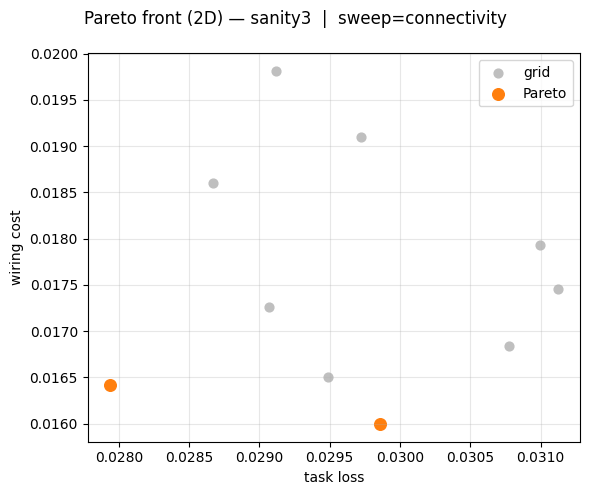

In [7]:
# Matplotlib: 2D Pareto plane for 1D sweeps, else 1x3 projection panels
pareto = df["is_pareto"].astype(bool)
battery = meta.get("task_battery", "")

if len(pareto_objectives) == 2:
    xc, yc = pareto_objectives
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df.loc[~pareto, xc], df.loc[~pareto, yc], c="0.75", s=40, label="grid")
    ax.scatter(df.loc[pareto, xc], df.loc[pareto, yc], c="C1", s=70, label="Pareto")
    ax.set_xlabel(OBJECTIVE_LABELS[xc])
    ax.set_ylabel(OBJECTIVE_LABELS[yc])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.suptitle(f"Pareto front (2D) — {battery}  |  sweep={sweep_mode}")
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    pairs = [
        ("task_loss", "metabolic_cost"),
        ("task_loss", "wiring_cost"),
        ("metabolic_cost", "wiring_cost"),
    ]
    for ax, (xc, yc) in zip(axes, pairs):
        ax.scatter(df.loc[~pareto, xc], df.loc[~pareto, yc], c="0.75", s=40, label="grid")
        ax.scatter(df.loc[pareto, xc], df.loc[pareto, yc], c="C1", s=70, label="Pareto")
        ax.set_xlabel(OBJECTIVE_LABELS[xc])
        ax.set_ylabel(OBJECTIVE_LABELS[yc])
        ax.grid(True, alpha=0.3)
    axes[0].legend(loc="best")
    fig.suptitle(f"Pareto front (2D projections) — {battery} ({len(df)} runs)")

fig.tight_layout()
plt.show()

In [ ]:
# Objectives vs lambda (1×3)
pareto = df["is_pareto"].astype(bool)
battery = meta.get("task_battery", "")
objective_cols = ["task_loss", "wiring_cost", "metabolic_cost"]

if sweep_mode in ("connectivity", "rate"):
    lam_col = "lambda_connectivity" if sweep_mode == "connectivity" else "lambda_rate"
    lam_label = "λ_connectivity" if sweep_mode == "connectivity" else "λ_rate"
    plot_df = df.sort_values(lam_col)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True)
    for ax, col in zip(axes, objective_cols):
        ax.plot(
            plot_df[lam_col],
            plot_df[col],
            "o-",
            color="0.55",
            markersize=5,
            linewidth=1.2,
            label="all runs",
        )
        p = plot_df.loc[plot_df["is_pareto"].astype(bool)]
        ax.scatter(p[lam_col], p[col], c="C1", s=70, zorder=3, label="Pareto")
        ax.set_ylabel(OBJECTIVE_LABELS[col])
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc="best", fontsize=8)
    fig.supxlabel(lam_label)
    fixed = (
        f"λ_rate = {df['lambda_rate'].iloc[0]:.4g}"
        if sweep_mode == "connectivity"
        else f"λ_conn = {df['lambda_connectivity'].iloc[0]:.4g}"
    )
    fig.suptitle(f"Objectives vs swept λ — {battery}  ({fixed})")
else:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for ax, col in zip(axes, objective_cols):
        sc = ax.scatter(
            df["lambda_rate"],
            df[col],
            c=df["lambda_connectivity"],
            cmap="viridis",
            s=45,
            alpha=0.85,
        )
        ax.scatter(
            df.loc[pareto, "lambda_rate"],
            df.loc[pareto, col],
            facecolors="none",
            edgecolors="C1",
            s=100,
            linewidths=1.8,
            label="Pareto",
        )
        ax.set_xlabel("λ_rate")
        ax.set_ylabel(OBJECTIVE_LABELS[col])
        ax.grid(True, alpha=0.3)
    axes[0].legend(loc="best", fontsize=8)
    fig.colorbar(sc, ax=axes, label="λ_connectivity", fraction=0.025, pad=0.02)
    fig.suptitle(f"Objectives vs λ_rate (color = λ_conn) — {battery}")

fig.tight_layout()
plt.show()

In [8]:
cols = ["lambda_rate", "lambda_connectivity", "task_loss", "metabolic_cost", "wiring_cost", "mean_acc", "is_pareto"]
df.sort_values(["task_loss", "metabolic_cost", "wiring_cost"])[cols]

,lambda_rate,lambda_connectivity,task_loss,metabolic_cost,wiring_cost,mean_acc,is_pareto
8,0.0,0.022778,0.027937,1.356308,0.016417,0.906250,True
2,0.0,0.009444,0.028670,1.373095,0.018596,0.895833,False
5,0.0,0.016111,0.029070,1.351584,0.017258,0.890625,False
0,0.0,0.005000,0.029118,1.228040,0.019811,0.911458,False
7,0.0,0.020556,0.029488,1.292542,0.016508,0.890625,False
1,0.0,0.007222,0.029725,1.276134,0.019097,0.906250,False
9,0.0,0.025000,0.029856,1.267348,0.015997,0.911458,True
6,0.0,0.018333,0.030774,1.257299,0.016836,0.911458,False
3,0.0,0.011667,0.030994,1.258493,0.017928,0.885417,False
4,0.0,0.013889,0.031122,1.215902,0.017459,0.875000,False
